In [163]:
import pyrtl
from pyrtl.rtllib.adders import *
from IPython.display import display_svg

In [19]:
import pyrtl.rtllib.libutils as rtlutils

x = int('00011000',2)

format(rtlutils.twos_comp_repr(-56, 8) , '08b')
result = format(rtlutils.twos_comp_repr(-56+x, 8) , '08b')
result

'11100000'

In [158]:
def get_const_offset(e_bits, m_bits):
    total_bits = e_bits + m_bits
    bias = (2**(e_bits-1) - 1) << m_bits
    
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l
    
    offset = rtlutils.twos_comp_repr(l-bias, total_bits)
    return offset
    
e4m3offset = get_const_offset(4,3)
print(e4m3offset)
print(format(e4m3offset, '0b'))

# Result in bounds
print("Normal case:")
result = e4m3offset + int('1111000',2)
result = format(result, '09b')
print(result, len(result))

# Result underflow
print("\nUnderflow case:")
result = e4m3offset + int('0001001',2)
result = format(result, '09b')
print(result, len(result))

# Result overflow
print("\nOverflow case:")
result = e4m3offset + int('11000000',2)
result = format(result, '09b')
print(result, len(result))


### Output
# Normal case:
# 011000001 9

# Underflow case:
# 001010010 9

# Overflow case:
# 100001001 9

73
1001001
Normal case:
011000001 9

Underflow case:
001010010 9

Overflow case:
100001001 9


In [ ]:
len('101000001000000')

15

In [144]:
(format(0b1111111 + 0b1111111, '0b'))

'11111110'

In [ ]:
len('101000001000000')

15

In [111]:
format(0b1111*2, '0b')

'11110'

In [85]:
len('101000001000000')

15

## $Lmul$ Implementation in PyRTL


In [168]:
pyrtl.reset_working_block()

In [ ]:
def lmul_hardware0():
    # Input/Output declarations
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split inputs into sign, exponent and mantissa
    sign_a = fp_a[7]
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]  # bits 0-6
    exp_mantissa_b = fp_b[0:7]  # bits 0-6

    # Calculate result sign using XOR
    result_sign = sign_a ^ sign_b

    # For E4M3 format:
    # - 4 exponent bits means bias of 7 (2^(4-1)-1)
    # - L(3) = 3 since mantissa bits <= 3
    # - Bias needs to be shifted left by mantissa bits (3) = 7 << 3 = 56
    BIAS_SHIFTED = pyrtl.Const(56, 7)  # 7 << 3 = 56 (0b0111000)
    L_OFFSET = pyrtl.Const(1, 7)  # L(3) = 3

    # Add exponents and mantissas together
    exp_mantissa_sum = exp_mantissa_a + exp_mantissa_b 

    # Add L(M) offset
    sum_with_offset = exp_mantissa_sum + L_OFFSET

    # Subtract bias
    result = pyrtl.WireVector(7)
    with pyrtl.conditional_assignment:
        with sum_with_offset >= BIAS_SHIFTED:
            result |= sum_with_offset - BIAS_SHIFTED
        with pyrtl.otherwise:
            result |= 0

    # Clamp to max value (0x7F = 127)
    clamped_result = pyrtl.WireVector(7)
    clamped_result <<= pyrtl.select(result > 0x7F, truecase=0x7F, falsecase=result)

    # Combine sign and result 
    fp_out <<= pyrtl.concat(result_sign, clamped_result)
    return fp_out


In [5]:
import os


In [6]:
os.environ["PATH"]

'c:\\Users\\kai.breese\\.conda\\envs\\dsc180;C:\\Users\\kai.breese\\.conda\\envs\\dsc180;C:\\Users\\kai.breese\\.conda\\envs\\dsc180\\Library\\mingw-w64\\bin;C:\\Users\\kai.breese\\.conda\\envs\\dsc180\\Library\\usr\\bin;C:\\Users\\kai.breese\\.conda\\envs\\dsc180\\Library\\bin;C:\\Users\\kai.breese\\.conda\\envs\\dsc180\\Scripts;C:\\Users\\kai.breese\\.conda\\envs\\dsc180\\bin;C:\\ProgramData\\anaconda3\\condabin;C:\\Program Files\\Eclipse Adoptium\\jdk-11.0.25.9-hotspot\\bin;C:\\Windows\\system32;C:\\Windows;C:\\Windows\\System32\\Wbem;C:\\Windows\\System32\\WindowsPowerShell\\v1.0;C:\\Windows\\System32\\OpenSSH;C:\\Program Files\\dotnet;C:\\Program Files (x86)\\dotnet-core-uninstall;C:\\Program Files\\nodejs;C:\\Program Files\\PowerShell\\7;C:\\Program Files\\Amazon\\AWSCLIV2;C:\\Program Files\\Git\\cmd;C:\\Program Files (x86)\\Common Files\\Oracle\\Java\\java8path;C:\\Program Files (x86)\\Common Files\\Oracle\\Java\\javapath;C:\\Program Files\\Eclipse Adoptium\\jdk-11.0.23.9-hotspo

In [ ]:
 += os.pathsep + "C:/Users/kai.breese/Downloads/windows_10_cmake_Release_Graphviz-12.1.2-win64/Graphviz-12.1.2-win64"

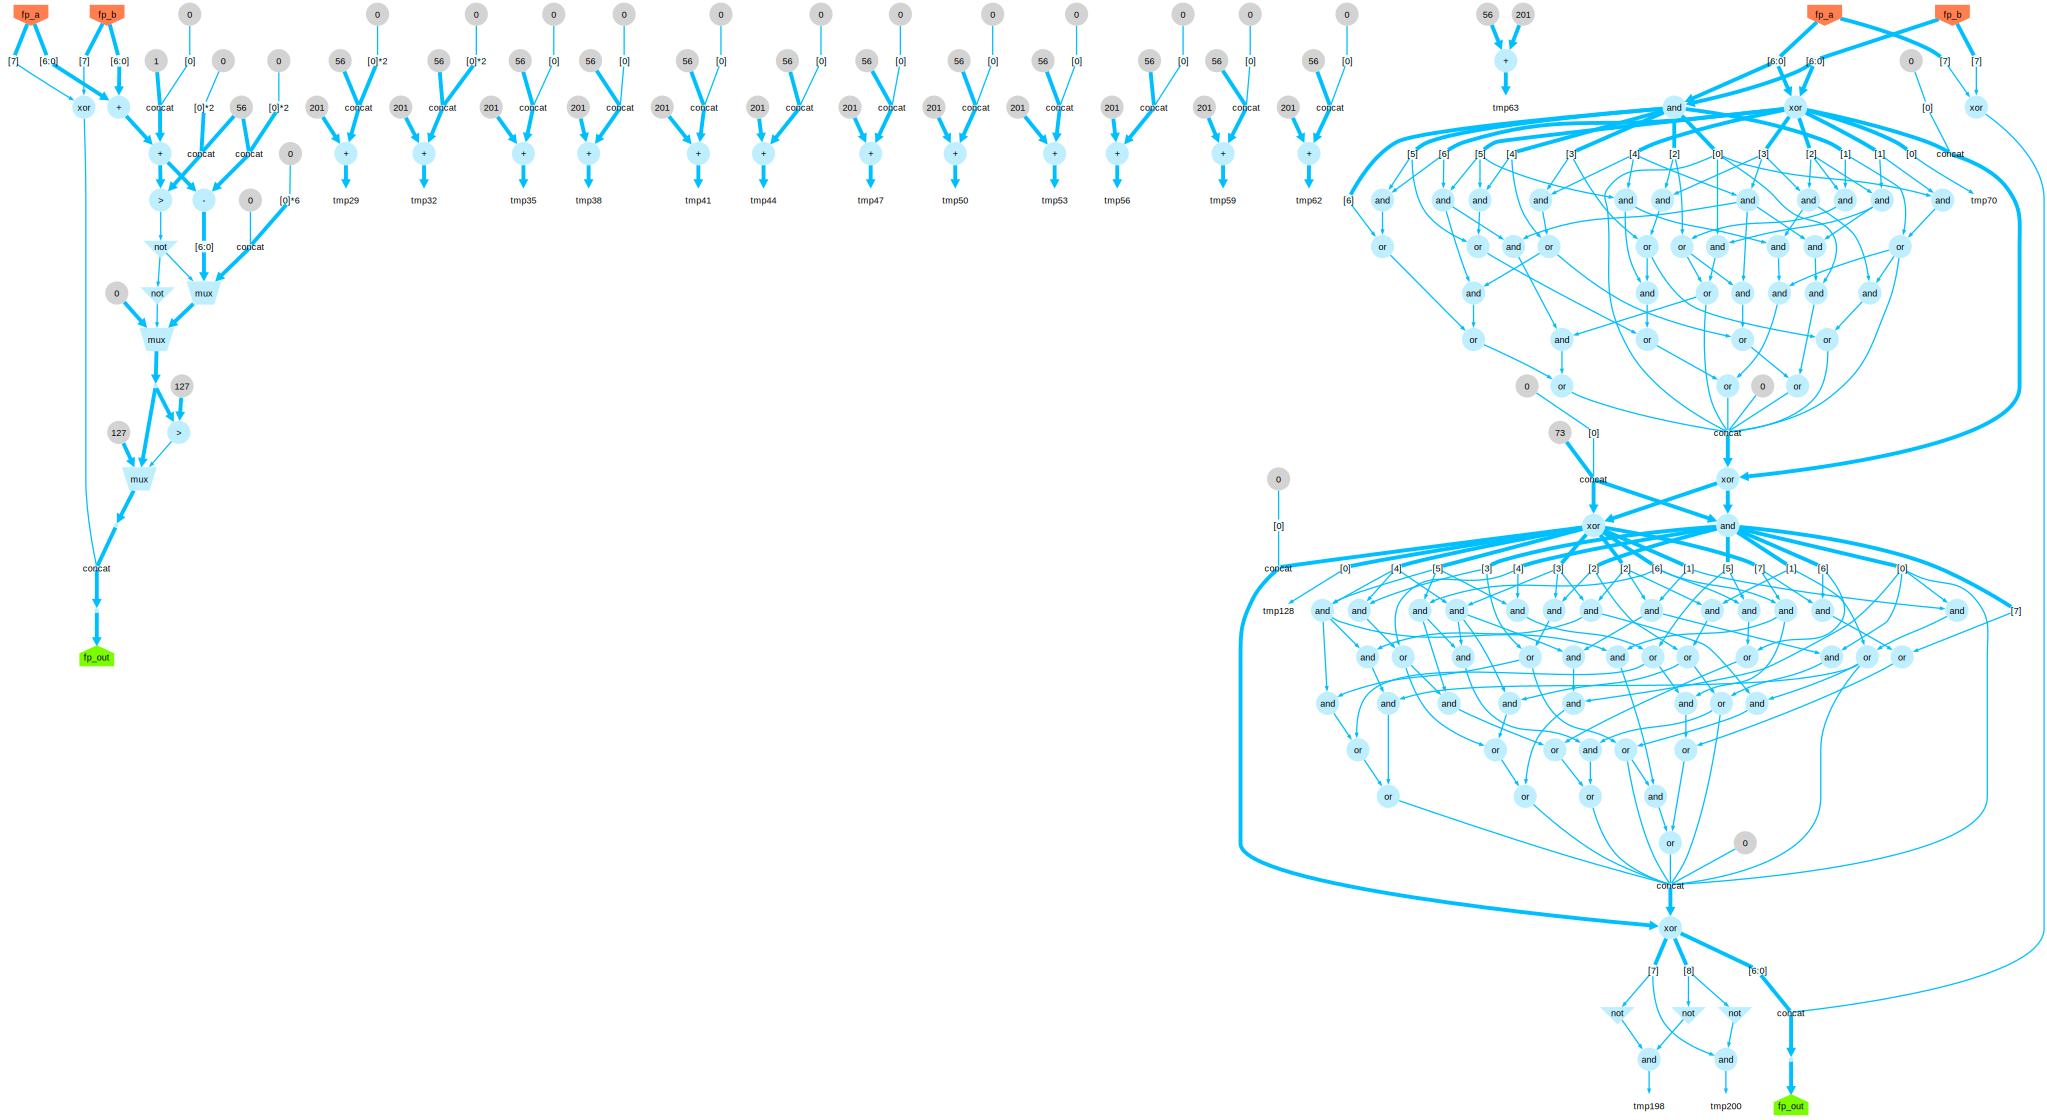

In [167]:
svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

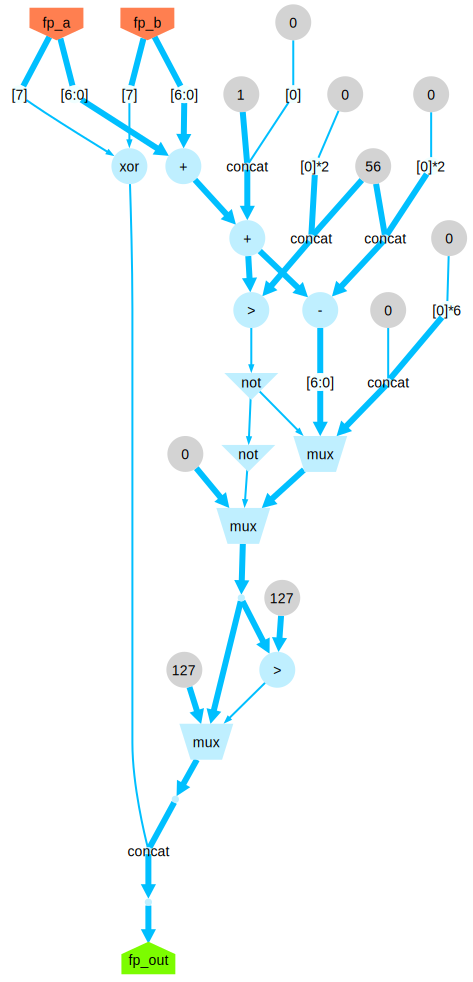

In [13]:
display_svg(svg, raw=True)

### Attempt 2


In [200]:
def lmul_hardware():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    
    # Extract carry and MSB for overflow/underflow detection
    carry = final_sum[8]  # 9th bit
    msb = final_sum[7]    # 8th bit
    result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with carry:
            mantissa_result = MAX_VALUE
        with ~carry & ~msb:
            mantissa_result = 0
        with ~carry & msb:
            mantissa_result = result_bits

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_hardware()

In [201]:
# Set up simulation
sim_trace = pyrtl.SimulationTrace()
sim = pyrtl.Simulation(tracer=sim_trace)

# Test vectors - let's test normal, overflow and underflow cases
test_vectors = [
    # Normal case: two small numbers
    (0x40, 0x40),  # inputs have exponent=4, mantissa=0
    
    # Overflow case: two large numbers
    (0x70, 0x70),  # inputs have large exponents
    
    # Underflow case: two small numbers
    (0x01, 0x01),  # inputs have very small values
    
    # Mixed signs
    (0xC0, 0x40),  # negative * positive
]

# Run simulation
for a, b in test_vectors:
    sim.step({
        'fp_a': a,
        'fp_b': b
    })

# Print the results
sim_trace.render_trace()

# You can also print specific values
print("\nDetailed Results:")
for i, (a, b) in enumerate(test_vectors):
    result = sim_trace.trace['fp_out'][i]
    print(f"fp_a: {format(a, '08b')} * fp_b: {format(b, '08b')} = fp_out: {format(result, '08b')}")

<IPython.core.display.Javascript object>


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00101001
fp_a: 00000001 * fp_b: 00000001 = fp_out: 01001011
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001


In [202]:
# Generating timing analysis information
print("Pre Synthesis:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

Pre Synthesis:
The total block timing delay is  1232.34


In [203]:
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=18)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

Estimated Area of block 2.338321420118343e-05 sq mm



In [204]:
est_area * 256*265

1.5863172514082837

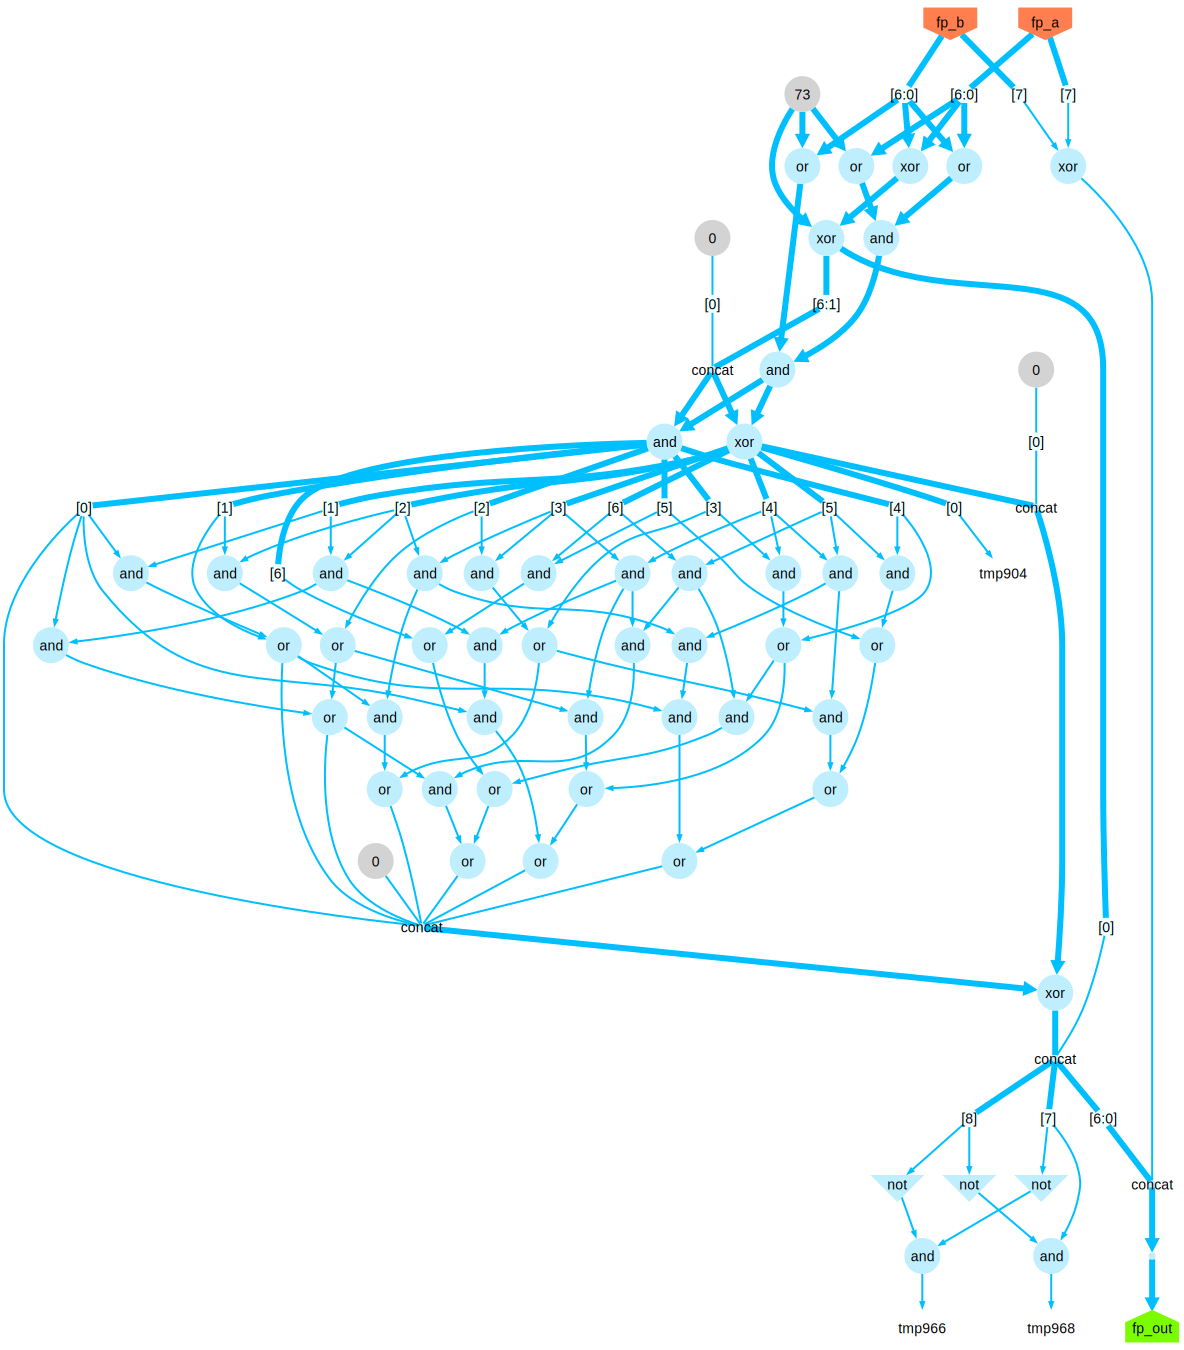

In [205]:
svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

In [206]:
pyrtl.synthesize()

print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
for net in pyrtl.working_block().logic:
    print(str(net))
print()

Pre Optimization:
The total block timing delay is  1232.34
tmp955\_synth\_5/1W & \leftarrow w \, - & tmp954\_synth\_0/1W  \\
tmp\_fp\_a\_synth\_4/1W & \leftarrow w \, - & tmp982/1W  \\
tmp953\_synth\_0/1W & \leftarrow w \, - & tmp1041/1W  \\
tmp907\_synth\_0/1W & \leftarrow w \, - & tmp903\_synth\_3/1W  \\
tmp\_fp\_out\_synth\_7/1W & \leftarrow w \, - & tmp969\_synth\_7/1W  \\
tmp1072/1W & \leftarrow \oplus \, - & tmp955\_synth\_0/1W, tmp957\_synth\_0/1W  \\
tmp1015/1W & \leftarrow \| \, - & tmp890\_synth\_1/1W, tmp891\_synth\_1/1W  \\
tmp1090/1W & \leftarrow \& \, - & tmp921\_synth\_0/1W, tmp926\_synth\_0/1W  \\
tmp946\_synth\_0/1W & \leftarrow w \, - & tmp1068/1W  \\
tmp960\_synth\_1/1W & \leftarrow w \, - & tmp958\_synth\_0/1W  \\
tmp960\_synth\_4/1W & \leftarrow w \, - & tmp958\_synth\_3/1W  \\
tmp894\_synth\_6/1W & \leftarrow w \, - & tmp1039/1W  \\
tmp922\_synth\_0/1W & \leftarrow w \, - & tmp1097/1W  \\
tmp913\_synth\_0/1W & \leftarrow w \, - & tmp911\_synth\_1/1W  \\
tmp901\_sy

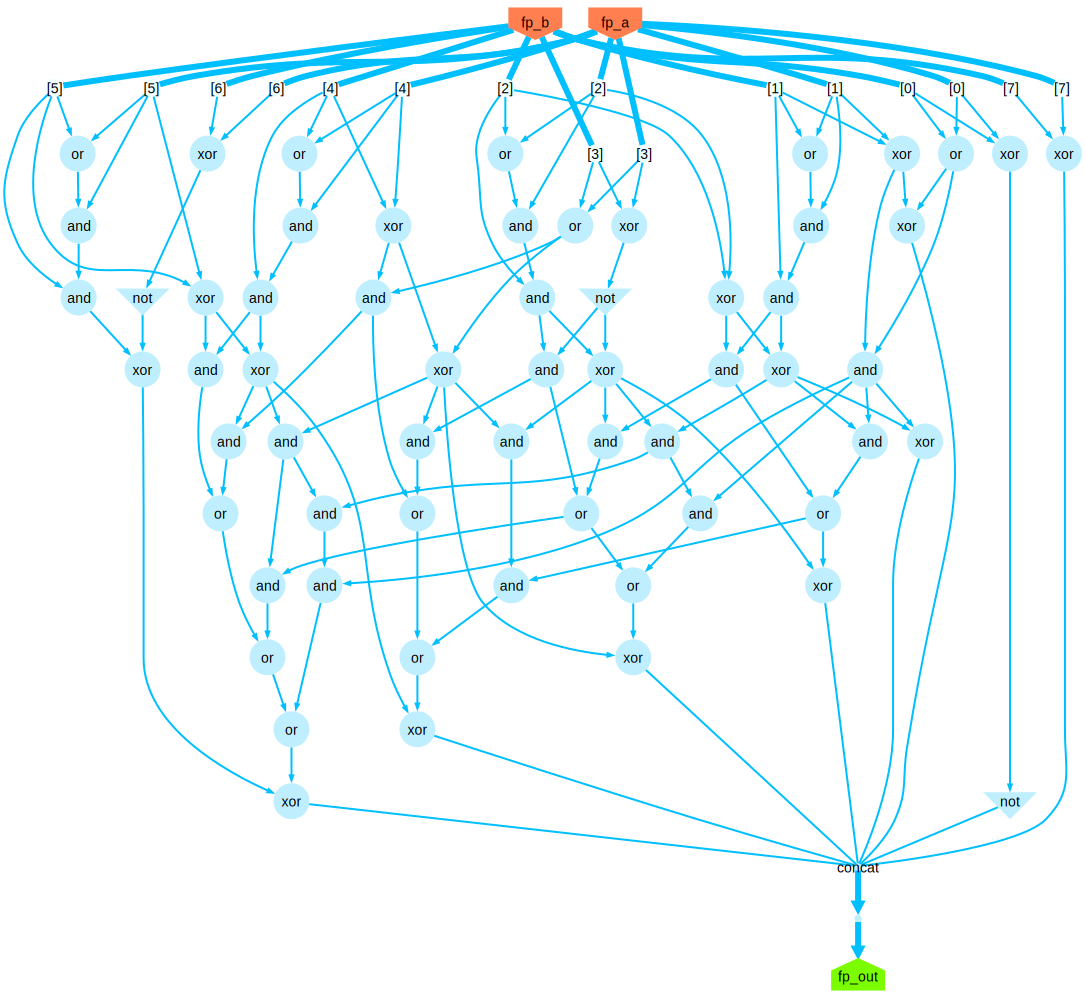

In [207]:
pyrtl.optimize()

In [208]:
print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

Post Optimization:
The total block timing delay is  1085.34


In [209]:
for net in pyrtl.working_block().logic:
    print(str(net))

tmp1000/1W & \leftarrow \oplus \, - & tmp982/1W, tmp974/1W  \\
tmp1085/1W & \leftarrow \& \, - & tmp1036/1W, tmp990/1W  \\
tmp1074/1W & \leftarrow \oplus \, - & tmp1069/1W, tmp1044/1W  \\
tmp1068/1W & \leftarrow \| \, - & tmp1022/1W, tmp987/1W  \\
tmp1076/1W & \leftarrow \oplus \, - & tmp1068/1W, tmp1046/1W  \\
tmp1026/1W & \leftarrow \& \, - & tmp1046/1W, tmp1045/1W  \\
tmp1066/1W & \leftarrow \& \, - & tmp1026/1W, tmp1013/1W  \\
tmp1014/1W & \leftarrow \| \, - & tmp978/1W, tmp970/1W  \\
tmp1083/1W & \leftarrow \& \, - & tmp997/1W, tmp1014/1W  \\
tmp1021/1W & \leftarrow \| \, - & tmp1087/1W, tmp1023/1W  \\
tmp1029/1W & \leftarrow \| \, - & tmp1099/1W, tmp1041/1W  \\
tmp985/1W & \leftarrow s \, - & fp\_a/8I ((7,)) \\
tmp1033/1W & \leftarrow \sim \, - & tmp996/1W  \\
tmp1028/1W & \leftarrow \& \, - & tmp1045/1W, tmp1085/1W  \\
tmp976/1W & \leftarrow s \, - & fp\_b/8I ((6,)) \\
tmp970/1W & \leftarrow s \, - & fp\_b/8I ((0,)) \\
tmp993/1W & \leftarrow \& \, - & tmp1011/1W, tmp975/1W  \\
t

### Attempt 3


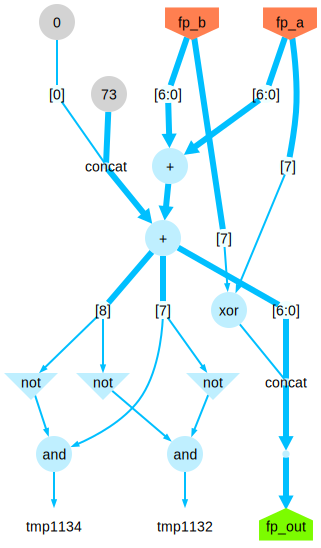

In [211]:
def lmul_hardware3():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    final_sum = exp_mantissa_a + exp_mantissa_b + OFFSET_MINUS_BIAS
    
    # Extract carry and MSB for overflow/underflow detection
    carry = final_sum[8]  # 9th bit
    msb = final_sum[7]    # 8th bit
    result_bits = final_sum[0:7]  # lower 7 bits

    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with carry:
            mantissa_result = MAX_VALUE
        with ~carry & ~msb:
            mantissa_result = 0
        with ~carry & msb:
            mantissa_result = result_bits

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_hardware3()

svg = pyrtl.block_to_svg(maintain_arg_order=True)
display_svg(svg, raw=True)